# Lesson 1.7: Introduction to Pandas

**Duration:** 3 Hours  
**Format:** Interactive Zoom Session

## 📋 Pre-Class Setup
Please run the cell below to ensure your environment is ready. We will use `numpy` and `pandas` throughout this lesson.

In [2]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)

Pandas version: 1.5.3
Numpy version: 1.26.4


---

## 🎯 Section 1: Creating & Modifying Data Structures (60 min)

### Learning Objectives (LO1)
By the end of this section, you will be able to:
- **Create** Series and DataFrames from raw data.
- **Modify** DataFrames by adding new columns and changing values.
- **Identify** the index and column components.
- **Detect** missing values using `isna()` and `notna()`.

### 📖 Concept: The Series
A Series is a one-dimensional array with labeled indices. It's the building block of a DataFrame.

In [3]:
# [DEMO] Creating a Series
obj = pd.Series([4, 7, -5, 3], index=["d", "b", "a", "c"])
obj

d    4
b    7
a   -5
c    3
dtype: int64

### 📖 Concept: The DataFrame
A DataFrame is a 2-dimensional labeled data structure. Think of it as a dictionary of Series objects (each column is a Series).

In [4]:
# [DEMO] Creating a DataFrame from a dictionary
data = {
    "state": ["Ohio", "Ohio", "Ohio", "Nevada", "Nevada", "Nevada"],
    "year": [2000, 2001, 2002, 2001, 2002, 2003],
    "pop": [1.5, 1.7, 3.6, 2.4, 2.9, 3.2]
}

frame = pd.DataFrame(data)
frame

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9
5,Nevada,2003,3.2


In [5]:
frame.head(2)

,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7


In [6]:
frame.describe()

,year,pop
count,6.000000,6.000000
mean,2001.500000,2.550000
std,1.048809,0.836062
min,2000.000000,1.500000
25%,2001.000000,1.875000
50%,2001.500000,2.650000
75%,2002.000000,3.125000
max,2003.000000,3.600000


In [7]:
frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   state   6 non-null      object 
 1   year    6 non-null      int64  
 2   pop     6 non-null      float64
dtypes: float64(1), int64(1), object(1)
memory usage: 272.0+ bytes


### 💡 Concept Demo: Inspecting & Modifying
1. `head()` and `tail()`
2. Accessing columns (dictionary syntax vs dot syntax)
3. Adding a new column

In [8]:
# [DEMO] Inspecting data
print("First 5 rows:")
display(frame.head())

# [DEMO] Accessing a column
print("Population column:")
display(frame['pop'])

First 5 rows:


,state,year,pop
0,Ohio,2000,1.5
1,Ohio,2001,1.7
2,Ohio,2002,3.6
3,Nevada,2001,2.4
4,Nevada,2002,2.9


Population column:


0    1.5
1    1.7
2    3.6
3    2.4
4    2.9
5    3.2
Name: pop, dtype: float64

In [9]:
# [DEMO] Adding a new column with a scalar value
frame['debt'] = 16.5
frame

,state,year,pop,debt
0,Ohio,2000,1.5,16.5
1,Ohio,2001,1.7,16.5
2,Ohio,2002,3.6,16.5
3,Nevada,2001,2.4,16.5
4,Nevada,2002,2.9,16.5
5,Nevada,2003,3.2,16.5


In [10]:
# [DEMO] Adding a calculated column
frame['eastern'] = frame.state == 'Ohio'
frame

,state,year,pop,debt,eastern
0,Ohio,2000,1.5,16.5,True
1,Ohio,2001,1.7,16.5,True
2,Ohio,2002,3.6,16.5,True
3,Nevada,2001,2.4,16.5,False
4,Nevada,2002,2.9,16.5,False
5,Nevada,2003,3.2,16.5,False


### 📖 Concept: Detecting Missing Data
Real-world data often has missing values (shown as `NaN`). Use `isna()` and `notna()` to detect them.

In [11]:
# [DEMO] Detecting missing values
data_with_nan = pd.Series([1, np.nan, 3.5, np.nan, 7])

print("Original data:")
display(data_with_nan)

print("\nWhich values are missing?")
display(data_with_nan.isna())

print("\nWhich values are NOT missing?")
display(data_with_nan.notna())

Original data:


0    1.0
1    NaN
2    3.5
3    NaN
4    7.0
dtype: float64


Which values are missing?


0    False
1     True
2    False
3     True
4    False
dtype: bool


Which values are NOT missing?


0     True
1    False
2     True
3    False
4     True
dtype: bool

### 🛠️ Activity: The Inventory System

**Scenario:** You manage a small grocery store. You need to track your fruit inventory.

**Tasks:**
1. Create a DataFrame named `inventory` from the provided dictionary `fruit_data`.
2. Add a new column `price` with values `[3.0, 4.0, 2.0, 5.0]`.
3. Add a column `total_value` which is `quantity * price`.
4. Create a boolean column `low_stock` that is `True` if quantity is less than 50.

In [12]:
# [EXERCISE] Starter Code
fruit_data = {
    "fruit": ["Apple", "Banana", "Cherry", "Date"],
    "quantity": [100, 40, 200, 20]
}

# 1. Create DataFrame
inventory = pd.DataFrame(fruit_data)

# 2. Add Price
inventory["price"] = [3.0, 4.0, 2.0, 5.0]

# 3. Calculate Total Value
inventory["total_value"] = inventory["quantity"] * inventory["price"]

# 4. Flag Low Stock
inventory["low_stock"] = inventory["quantity"] < 50

# Display result
inventory

,fruit,quantity,price,total_value,low_stock
0,Apple,100,3.0,300.0,False
1,Banana,40,4.0,160.0,True
2,Cherry,200,2.0,400.0,False
3,Date,20,5.0,100.0,True


---

## 🎯 Section 2: Indexing and Selection (60 min)

### Learning Objectives (LO2)
By the end of this section, you will be able to:
- **Differentiate** between label-based (`loc`) and position-based (`iloc`) indexing.
- **Apply** boolean filtering to select specific rows.
- **Drop** rows or columns from a DataFrame.
- **Modify** specific data points using selection.

In [13]:
# Setup for Demo
data = pd.DataFrame(np.arange(16).reshape((4, 4)),
                    index=["Ohio", "Colorado", "Utah", "New York"],
                    columns=["one", "two", "three", "four"])
data

,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


In [14]:
data.loc["Colorado"]

one      4
two      5
three    6
four     7
Name: Colorado, dtype: int64

### 💡 Concept Demo: Loc vs Iloc
- **.loc[row_label, col_label]**: "Address" based.
- **.iloc[row_pos, col_pos]**: "GPS" based (integers).

In [15]:
# [DEMO] Select 'Colorado' row using loc
print("--- Row by Label ---")
display(data.loc["Colorado"])

# [DEMO] Select 'Colorado' row using iloc (it's at index 1)
print("\n--- Row by Position ---")
display(data.iloc[1])

--- Row by Label ---


one      4
two      5
three    6
four     7
Name: Colorado, dtype: int64


--- Row by Position ---


one      4
two      5
three    6
four     7
Name: Colorado, dtype: int64

In [16]:
# [DEMO] Boolean Filtering
# Select rows where column 'three' is greater than 5
data[data["three"] > 5]

,one,two,three,four
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


### 📖 Concept: Dropping Rows and Columns
Use the `drop()` method to remove rows or columns. By default, it drops rows. Use `axis=1` or `axis="columns"` to drop columns.

In [17]:
# [DEMO] Dropping rows and columns
print("Drop rows 'Colorado' and 'Ohio':")
display(data.drop(["Colorado", "Ohio"]))

print("\nDrop column 'two':")
display(data.drop("two", axis=1))

Drop rows 'Colorado' and 'Ohio':


,one,two,three,four
Utah,8,9,10,11
New York,12,13,14,15



Drop column 'two':


,one,three,four
Ohio,0,2,3
Colorado,4,6,7
Utah,8,10,11
New York,12,14,15


### 🛠️ Activity: Data Detective

**Tasks:**
Using the `data` DataFrame provided above:
1. Select the rows for 'Utah' and 'New York' only.
2. Select the value in the 'two' column for 'Ohio' (should be 1).
3. Select all rows where column 'three' is greater than 5.
4. Update the value of 'four' in the 'New York' row to be 100.

In [18]:
# [EXERCISE] Write your code here

# 1. Utah and New York
# Select the rows for 'Utah' and 'New York' only
display(data.loc[['Utah', 'New York']])

# 2. 'two' for 'Ohio'
# Select the value in the 'two' column for 'Ohio' (should be 1).
display(data.loc['Ohio', 'two'])

# 3. Filter > 5
# Select all rows where column 'three' is greater than 5
display(data.loc[data['three'] > 5])

# 4. Update value
# Update the value of 'four' in the 'New York' row to be 100.
data.loc['New York', 'four'] = 100
display(data)

,one,two,three,four
Utah,8,9,10,11
New York,12,13,14,15


1

,one,two,three,four
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,15


,one,two,three,four
Ohio,0,1,2,3
Colorado,4,5,6,7
Utah,8,9,10,11
New York,12,13,14,100


---

## 🎯 Section 3: Function Application, Sorting, & Ranking (60 min)

### Learning Objectives (LO3 & LO4)
By the end of this section, you will be able to:
- **Sort** data by index or values.
- **Rank** data to handle ties.
- **Apply** custom functions to transform data.

In [19]:
# Setup Data
frame = pd.DataFrame({
    "b": [4, 7, -3, 2], 
    "a": [0, 1, 0, 1]
}, index=['Row1', 'Row2', 'Row3', 'Row4'])
frame

,b,a
Row1,4,0
Row2,7,1
Row3,-3,0
Row4,2,1


### 💡 Concept Demo: Sorting & Ranking
1. `sort_index()`
2. `sort_values(by=...)`
3. `rank()`

In [20]:
# [DEMO] Sort by values in column 'b'
frame.sort_values(by="b")

,b,a
Row3,-3,0
Row4,2,1
Row1,4,0
Row2,7,1


In [21]:
# [DEMO] Applying a function
def label_size(val):
    return "Big" if val > 2 else "Small"

frame['b_size'] = frame['b'].apply(label_size)
frame

,b,a,b_size
Row1,4,0,Big
Row2,7,1,Big
Row3,-3,0,Small
Row4,2,1,Small


### 🛠️ Activity: Leaderboard Logic

**Scenario:** You have exam scores. You need to rank them and assign a Pass/Fail status.

**Tasks:**
1. Run the starter code to generate the `scores` DataFrame.
2. Sort the DataFrame by 'Math' score in descending order (highest first).
3. Create a new column 'Math_Rank' using the `.rank()` method.
4. Define a function that returns "Pass" if score >= 60 and "Fail" otherwise.
5. Apply this function to the 'Math' column to create a new 'Status' column.

In [22]:
# [EXERCISE] Starter Code
scores = pd.DataFrame({
    "Student": ["Alice", "Bob", "Charlie", "David"],
    "Math": [85, 45, 92, 60],
    "Science": [70, 55, 88, 72]
})

# Your code here
# Sort the DataFrame by 'Math' score in descending order (highest first).
display(scores.sort_values(by="Math", ascending=False))

# Create a new column 'Math_Rank' using the `.rank()` method.
display(scores.assign(Math_Rank=scores['Math'].rank(ascending=False)))

,Student,Math,Science
2,Charlie,92,88
0,Alice,85,70
3,David,60,72
1,Bob,45,55


,Student,Math,Science,Math_Rank
0,Alice,85,70,2.0
1,Bob,45,55,4.0
2,Charlie,92,88,1.0
3,David,60,72,3.0


In [23]:
# Define a function that returns "Pass" if score >= 60 and "Fail" otherwise
def grade(score):
    if score >= 60:
        return "Pass"
    else:
        return "Fail"
    

# Apply this function to the 'Math' column to create a new 'Status' column.
scores['Status'] = scores['Math'].apply(grade)
display(scores)

,Student,Math,Science,Status
0,Alice,85,70,Pass
1,Bob,45,55,Fail
2,Charlie,92,88,Pass
3,David,60,72,Pass


## 🎓 Lesson Summary

1. **Data Structures:** Series (1D) and DataFrame (2D) are the building blocks.
2. **Missing Data:** Use `isna()` and `notna()` to detect missing values.
3. **Selection:** Use `.loc[]` for labels and `.iloc[]` for positions. Use `.drop()` to remove rows/columns.
4. **Operations:** Vectorized operations are faster than loops. Use `.apply()` for custom logic.
5. **Sorting:** Organize your data to find insights quickly.

**Next Steps:** In the next lesson, we will cover Data Cleaning (handling missing values) and Aggregation (GroupBy).

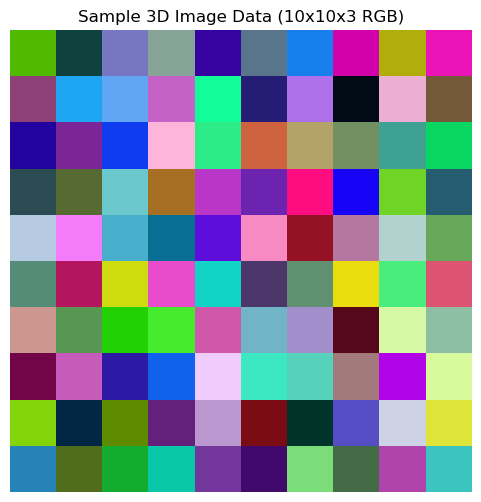

Image data as DataFrame:
     R    G    B
0   80  186    3
1   15   66   63
2  119  118  194
3  134  165  151
4   55    3  160


In [4]:
import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt

# Generate a sample image array (3D: height x width x channels)
image_3d = np.random.randint(0, 256, size=(10, 10, 3), dtype=np.uint8)

# Display the image
plt.figure(figsize=(6, 6))
plt.imshow(image_3d)
plt.title("Sample 3D Image Data (10x10x3 RGB)")
plt.axis('off')
plt.show()

# Convert to DataFrame for analysis
image_flat = image_3d.reshape(-1, 3)
image_df = pd.DataFrame(image_flat, columns=['R', 'G', 'B'])
print("Image data as DataFrame:")
print(image_df.head())

In [5]:
# display the shape and dimensions of the image data
print("\nImage shape:", image_3d.shape)
print("Image dimensions:", image_3d.ndim)


Image shape: (10, 10, 3)
Image dimensions: 3


In [6]:
# display the shape and dimensions of the image data from image_df
print("\nDataFrame shape:", image_df.shape)
print("DataFrame dimensions:", image_df.ndim)


DataFrame shape: (100, 3)
DataFrame dimensions: 2


NumPy sees the original image as a 3D array (height × width × color channels), but once the pixel values are loaded into a DataFrame, Pandas only sees a 2D structure of rows and columns.

A DataFrame is fundamentally 2-dimensional:

- rows
- columns

Pandas can mimic 3D data using MultiIndex 

In [7]:
# Create MultiIndex for a panel-like DataFrame
stores = ["Store A", "Store B", "Store C"]
quarters = ["Q1", "Q2", "Q3", "Q4"]

index = pd.MultiIndex.from_product([stores, quarters], names=["Store", "Quarter"])

# Create MultiIndex columns for different metrics
metrics = ["Sales", "Profit", "Expenses"]
columns = pd.MultiIndex.from_product([metrics, ["2024", "2025"]], names=["Metric", "Year"])

panel_df = pd.DataFrame(
    np.random.randint(50, 200, size=(len(index), len(columns))),
    index=index,
    columns=columns
)

panel_df

Metric          Sales      Profit      Expenses     
Year             2024 2025   2024 2025     2024 2025
Store   Quarter                                     
Store A Q1        146   89     63   84      105  194
        Q2        106  149    159   64       86   90
        Q3        153  131    132  167      184   76
        Q4         92  173    121  141      137  123
Store B Q1         53   70    155   94      112  187
        Q2         59   63    127  134      139   85
        Q3        185   62    177  134      167  185
        Q4         58  101    117   76      148   86
Store C Q1         65  146    154  142      109  115
        Q2        137  184     70  144       96  181
        Q3        172  142    107   62      156  107
        Q4        194   58     78  147      161  153

In [9]:
# print the shape and dimensions of the panel DataFrame
print("\nPanel DataFrame shape:", panel_df.shape)
print("Panel DataFrame dimensions:", panel_df.ndim)


Panel DataFrame shape: (12, 6)
Panel DataFrame dimensions: 2


Why Pandas Removed True 3D Support
